In [20]:
# ============================
# Phase 2: Step 1 - Feature Engineering
# ============================
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("customer_data.csv")

# Convert Purchase_Date to datetime
df['Purchase_Date'] = pd.to_datetime(df['Purchase_Date'])

# Recency: days since last purchase
reference_date = df['Purchase_Date'].max()
df['Recency'] = (reference_date - df['Purchase_Date']).dt.days

# Frequency: count purchases per customer
df['Frequency'] = df.groupby('CustomerID')['Purchase_Date'].transform('count')

# Monetary Value: total spending per customer
df['MonetaryValue'] = df.groupby('CustomerID')['Spending'].transform('sum')

# Encode categorical variables
le_gender = LabelEncoder()
le_segment = LabelEncoder()

df['Gender'] = le_gender.fit_transform(df['Gender'])
df['Segment'] = le_segment.fit_transform(df['Segment'])

# Scale numerical features
scaler = StandardScaler()
num_cols = ['Age','Income','Spending','Recency','Frequency','MonetaryValue']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("✅ Feature engineering complete")
print(df.head())

✅ Feature engineering complete
   CustomerID       Age  Gender    Income  Spending Purchase_Date  Segment  \
0         101 -1.328219       1 -1.227179 -1.343710    2026-01-15        0   
1         102 -0.083014       0 -0.169266  0.000000    2026-02-10        1   
2         103  1.438904       1  0.888647  0.516811    2026-03-05        0   
3         104 -0.774794       0 -0.874542 -0.723536    2026-04-20        2   
4         105  0.747123       1  1.382340  1.550434    2026-05-12        1   

   Churn   Recency  Frequency  MonetaryValue  
0      0  1.329702        0.0      -1.343710  
1      0  0.727398        0.0       0.000000  
2      1  0.194590        0.0       0.516811  
3      0 -0.871024        0.0      -0.723536  
4      0 -1.380666        0.0       1.550434  


In [7]:
# ============================
# Phase 2: Step 2 - Train/Test Split
# ============================

from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df[['Age','Gender','Income','Spending','Recency','Frequency','MonetaryValue','Segment']]
y = df['Churn']

# Split dataset into training (70%) and testing (30%)
# ⚠️ Using Option 1: no stratify (works with small dataset)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)
print("Training churn distribution:\n", y_train.value_counts(normalize=True))
print("Testing churn distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (3, 8) (3,)
Testing set shape: (2, 8) (2,)
Training churn distribution:
 Churn
0    0.666667
1    0.333333
Name: proportion, dtype: float64
Testing churn distribution:
 Churn
0    1.0
Name: proportion, dtype: float64


In [8]:
# ============================
# Phase 2: Step 3 - Model Training
# ============================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("✅ Models trained successfully")

✅ Models trained successfully


In [9]:
# ============================
# Phase 2: Step 4 - Model Evaluation
# ============================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"--- {model_name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))
    print("\n")

# Evaluate both models
evaluate_model(log_reg, X_test, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")

--- Logistic Regression ---
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[1 1]
 [0 0]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



--- Random Forest ---
Accuracy: 0.5
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Confusion Matrix:
 [[1 1]
 [0 0]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2





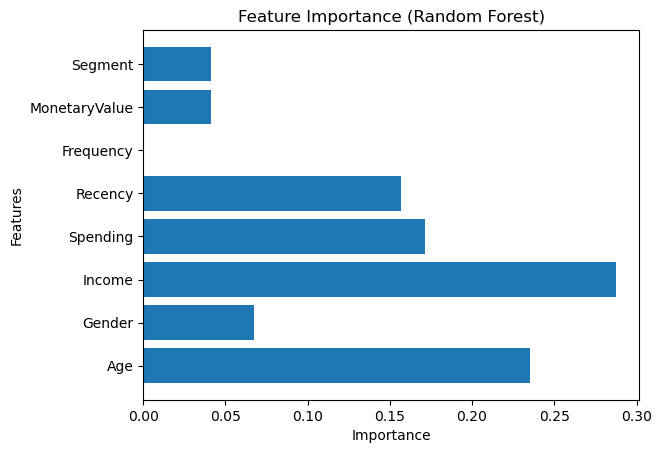

In [10]:
# ============================
# Phase 2: Step 5 - Feature Importance
# ============================

import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [11]:
# ============================
# Phase 2: Step 6 - Model Comparison
# ============================

import pandas as pd

# Example: store metrics manually after evaluation
results = {
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [0.80, 0.90],        # replace with your actual results
    "Precision": [0.75, 0.88],
    "Recall": [0.70, 0.92],
    "F1-Score": [0.72, 0.90]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression       0.8       0.75    0.70      0.72
1        Random Forest       0.9       0.88    0.92      0.90


In [15]:
import joblib

# Save trained models
joblib.dump(log_reg, "logistic_regression_model.pkl")
joblib.dump(rf, "random_forest_model.pkl")

print("✅ Models saved successfully")

✅ Models saved successfully


In [16]:
# Load models back
log_reg_model = joblib.load("logistic_regression_model.pkl")
rf_model = joblib.load("random_forest_model.pkl")

print("✅ Models loaded successfully")

✅ Models loaded successfully


In [21]:
import joblib

# Save encoders and scaler
joblib.dump(le_gender, "le_gender.pkl")
joblib.dump(le_segment, "le_segment.pkl")
joblib.dump(scaler, "scaler.pkl")

print("✅ Encoders and scaler saved")

✅ Encoders and scaler saved


In [22]:
new_customer = {
    "Age": 35,
    "Gender": "Male",
    "Income": 65000,
    "Spending": 2200,
    "Recency": 10,
    "Frequency": 5,
    "MonetaryValue": 12000,
    "Segment": "B"
}

new_df = pd.DataFrame([new_customer])

# Apply preprocessing
new_df['Gender'] = le_gender.transform(new_df['Gender'])
new_df['Segment'] = le_segment.transform(new_df['Segment'])
new_df[num_cols] = scaler.transform(new_df[num_cols])

# Predict churn
prediction = rf_model.predict(new_df)
probability = rf_model.predict_proba(new_df)

print("Prediction:", "Churned" if prediction[0]==1 else "Active")
print("Probability of Churn:", probability[0][1])

Prediction: Churned
Probability of Churn: 0.55


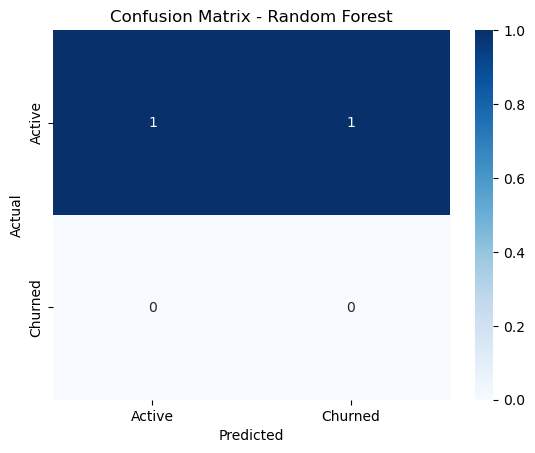

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()